10000


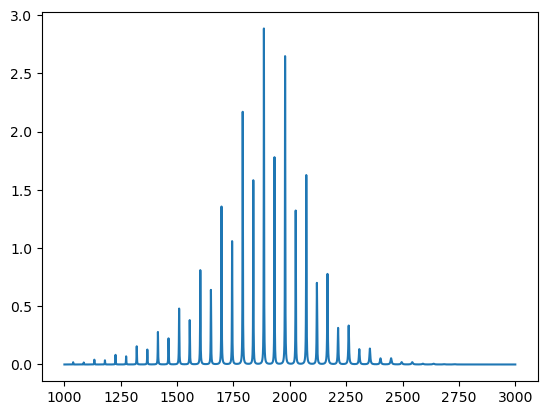

In [79]:
import astropy
import numpy as np
from pathlib import Path
from astropy.nddata import CCDData
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
import glob


mass_star = 1.21
r_star = 1.357
teff_star = 6163
nu_max_sun_uHz = 3090.0
teff_sun_K = 5777.0
max_rms_amplitude_sun = 2.1
delta_nu_sun = 135.1
epsilon = 1.55
    
def calc_maximum_rms_amplitude_radial(mass_star, teff_star):
    luminosity_ratio = (r_star**2) * (teff_star / teff_sun_K) ** 4
    power = -0.093
    t_red_star = 8907*(luminosity_ratio**power)
    delta_t = 1250
    dwarf_suppression_beta = 1 - np.exp((teff_star - t_red_star)/(delta_t))

    max_rms_amplitude_star = max_rms_amplitude_sun * dwarf_suppression_beta * luminosity_ratio *(mass_star**-1) * ((teff_star / teff_sun_K) ** (-2))   
    
    return max_rms_amplitude_star


l = np.linspace(0,3,4)
n = np.linspace(0,30,31)
V = [1, 1.505, 0.620, 0.075]

    
def calc_nl_rms_amplitude_radial(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    #print(nu_max)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    
    #nu_nl.append(delta_nu * (n + (l/2) + epsilon))
    
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    envelope_FWHM = 0.66 * (nu_max ** 0.88)
    
    if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
                
    width_envelope = envelope_FWHM / (2 * np.sqrt(2*np.log(2)))
        
    nl_rms_ampliude_star = (((calc_maximum_rms_amplitude_radial(mass_star, teff_star) ** 2) * np.exp(-((nu_nl - nu_max)**2)/(2*(width_envelope**2))))**0.5)
    
    return nl_rms_ampliude_star


def width_parameter(mass_star, teff_star, a, b):
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    P = (a*(nu_max/3090)) + b
    return P

alpha = width_parameter(mass_star, teff_star, 2.95, 0.39)
width_alpha = width_parameter(mass_star, teff_star, 3.08, 3.32)
delta_width_dip = width_parameter(mass_star, teff_star, -0.47, 0.62)
W_dip = width_parameter(mass_star, teff_star, 4637, -141)
nu_dip = width_parameter(mass_star, teff_star, 2984, 60)

def calc_width_nl(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    Lnwidth = ((alpha * np.log(nu_nl/nu_max)) + np.log(width_alpha)) + (np.log(delta_width_dip)/(1 + (((2 * np.log(nu_nl/nu_dip))/(np.log(W_dip/nu_max)))**2)))
    width_nl = np.exp(Lnwidth)

    return width_nl

def lorentz(freq, centroid, FWHM): 
    #scale parameter is the half-width-half-maximum value of the Lorentz curve
    return (1/np.pi) * ((FWHM/2) / ((freq - centroid)**2 + (FWHM/2)**2))

def calc_power_amplitude(amp,width):
    return (2/np.pi)*((amp**2)/width)



nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
envelope_FWHM = 0.66 * (nu_max ** 0.88)
delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))

if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
#print(envelope_FWHM)

standev_envelope = envelope_FWHM / (2*np.sqrt(2*np.log(2)))
nu_envelope_min = nu_max - (3*standev_envelope)
nu_envelope_max = nu_max + (3*standev_envelope)

n_min = []
n_max = []

for i in l:
    n_min.append(int((nu_envelope_min/delta_nu) - ((i/2) + epsilon)))
    n_max.append(int((nu_envelope_max/delta_nu) - ((i/2) + epsilon)))

nu_range = np.linspace(1000,3000,10000)
#power_density = np.zeros(len(nu_range))
power_density = np.zeros(len(nu_range))

for j in l:
    #power_density = np.zeros(len(nu_range))
    
    for i in np.linspace(min(n_min), max(n_max), (max(n_max)-min(n_min))+1):
        nu_nl = delta_nu * (i + (j/2) + epsilon)
        amplitude_nl =V[int(j)] * calc_nl_rms_amplitude_radial(mass_star, teff_star, i, j)
        width_nl = calc_width_nl(mass_star, teff_star, i, j)
        power_amplitude = calc_power_amplitude(amplitude_nl, width_nl)
        power_density +=(power_amplitude * lorentz(nu_range, nu_nl, width_nl))
    
plt.plot(nu_range, power_density)
print(len(power_density))

In [73]:
#PIC = fits.util.get_testdata_filepath('data/LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits')
PIC = fits.open('LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits') #see group projects canvas page
#headers = np.asarray(PIC[1].header)
data = np.asarray(PIC[1].data)
print(f"{len(data["PICid"])} entries")

309787 entries


In [74]:
myepictable = []

for i in range(len(data["Mass"])):
    if data["Mass"][i] < 1.5:
        myepictable.append(data[i])

data_reduced = np.asarray(myepictable)

In [75]:
print(f"{data_reduced["Mass"][0]} solar masses, {data_reduced["Radius"][0]} solar radii, {data_reduced["Teff"][0]} K")

0.553082617452391 solar masses, 0.528597868558916 solar radii, 3706.57015580926 K


In [76]:
#M = data_reduced["Mass"] #grabs the masses of the relevent stars in PIC, in solar masses
#R = data_reduced["Radius"] #grabs the radii of the relevent stars in PIC, in solar radii
#T = data_reduced["Teff"] #grabs the temperatures of the relevent stars in PIC, in Kelvin
#solar mass = 1.989 × 10^30 kg
#solar radius = 696,340 km
#solar temp = 5778 K


def max_freq(M, R, T):
    solar_temp = 5778
    dT = T / solar_temp
    return( float(M * R**(-2) * dT**(-0.5)) ) #returns max frequency in terms of max frequency of the Sun

def tau_gran(M, R, T):
    tau_gran_sun = 250 #characteristic timescale of granulation for the Sun
    return( float( ( max_freq(M, R, T) )**(-1) * tau_gran_sun) ) #returns the characteristic timescale of granulation for the star

def lumin(M, R, T):    
    solar_lum = 3.828 * 10**26
    solar_temp = 5772
    return( float(R**2 * (T / solar_temp)**4) ) #returns luminosity 

def granulation_amplitude(M, R, T):
    max_freq_sun = 3090
    granulation_amplitude_sun = 1 #currently unknown, ask about
    return( float(granulation_amplitude_sun * (lumin(M, R, T)**2 * max_freq(M, R, T)) / (M**3 * (T / 5778)**5.5)) ) #1.989*10**30, 3.828 * 10**26

def power_spec_granulation(M, R, T, freq):
    return( ( 4 * granulation_amplitude(M, R, T)**2 * tau_gran(M, R, T) ) / (1 + (2 * np.pi * freq * 10**-6 * tau_gran(M, R, T))**4 ) )

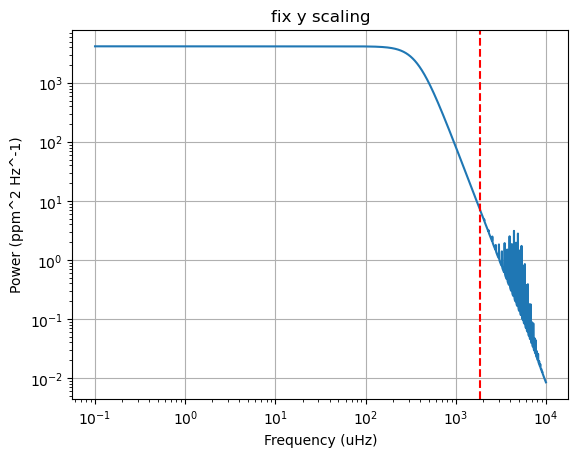

In [80]:
f = np.linspace(10**-1, 10**4, 10000)
star_input = -1
P = power_density + power_spec_granulation(data_reduced["Mass"][star_input], data_reduced["Radius"][star_input], data_reduced["Teff"][star_input], f)
#P = power_spec_granulation(1.223, 1.357, 6325, f)

#print( max_freq(1.223, 1.357, 6325) )
#print( granulation_amplitude(1.223, 1.357, 6325) )
#print( lumin(1.223, 1.357, 6325) )

plt.loglog(f, P)
plt.axvline(max_freq(data_reduced["Mass"][star_input], data_reduced["Radius"][star_input], data_reduced["Teff"][star_input]) * 3100, ls='--', color='r')
plt.grid(which='major')
plt.title("fix y scaling")
plt.ylabel("Power (ppm^2 Hz^-1)")
plt.xlabel("Frequency (uHz)")
plt.show()